In [7]:
# Установка зависимостей
!pip install torch transformers datasets seqeval scikit-learn sentencepiece matplotlib accelerate gliner


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


=== ML-метки (train / val) ===
         Train (scanpatch+synth CVC)  Val (scanpatch test+hive CVC)
ADDRESS                         7362                            735
CVC                             1000                             70
NAME                            8987                            964

Синтетических CVC в train: 1000
Hivetrace CVC в val: 70

=== Все типы в hivetrace domain split (900 текстов) ===
                  Entities
ADDRESS                106
BANK_CARD_NUMBER        22
CVC                      7
EMAIL                  103
INN                     48
KPP                     24
NAME                   158
OGRN                    23
OGRNIP                  17
PASSPORT_NUMBER         50
PHONE_NUMBER           147
SNILS                   27
TOKEN                   25


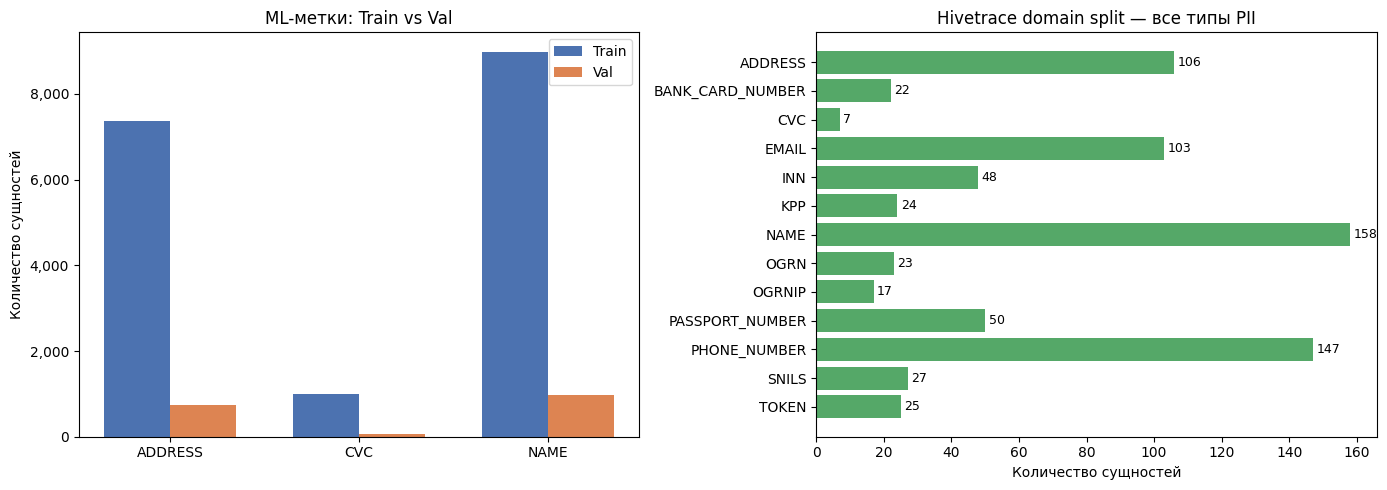

In [13]:
# EDA: распределение сущностей в обучающей и валидационной выборках
import json
import pathlib
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datasets import load_dataset
from data import SCANPATCH_TO_ML, ML_LABELS

sp    = load_dataset("scanpatch/pii-ner-corpus-synthetic-controlled")
bench = load_dataset("hivetrace/pii-bench")

# ── Scanpatch train → NAME/ADDRESS ──────────────────────────────────────────
sp_train_counts = Counter()
for row in sp["train"]:
    for lbl in row["entity_labels"]:
        ml = SCANPATCH_TO_ML.get(lbl)
        if ml:
            sp_train_counts[ml] += 1

# ── Scanpatch test → NAME/ADDRESS ───────────────────────────────────────────
sp_val_counts = Counter()
for row in sp["test"]:
    for lbl in row["entity_labels"]:
        ml = SCANPATCH_TO_ML.get(lbl)
        if ml:
            sp_val_counts[ml] += 1

# ── Hivetrace entity split → CVC (идёт в валидацию) ────────────────────────
hive_entity_counts = Counter()
for row in bench["entity"]:
    for e in row["entities"]:
        lbl = e.get("type", e.get("label", ""))
        if lbl in ML_LABELS:
            hive_entity_counts[lbl] += 1

# ── Hivetrace domain split → все типы (финальный бенчмарк) ──────────────────
hive_domain_counts = Counter()
for row in bench["domain"]:
    for e in row["entities"]:
        lbl = e.get("type", e.get("label", ""))
        hive_domain_counts[lbl] += 1

# ── Синтетические CVC из ner_cvc_1000.json (идут в обучение) ────────────────
synthetic_cvc_count = 0
_p = pathlib.Path("ner_cvc_1000.json")
if _p.exists():
    synthetic_cvc_count = sum(
        1 for row in json.load(open(_p, encoding="utf-8"))
        for e in row["entities"] if e["type"] == "CVC"
    )

# ── Train = scanpatch train + synthetic CVC ──────────────────────────────────
train_counts = sp_train_counts.copy()
train_counts["CVC"] += synthetic_cvc_count

# ── Val = scanpatch test + hivetrace CVC ────────────────────────────────────
val_counts = sp_val_counts.copy()
val_counts["CVC"] += hive_entity_counts.get("CVC", 0)

# ── Вывод числами ────────────────────────────────────────────────────────────
import pandas as pd

all_ml_labels = sorted(ML_LABELS)
domain_labels = sorted(hive_domain_counts)

print("=== ML-метки (train / val) ===")
df_ml = pd.DataFrame({
    "Train (scanpatch+synth CVC)": [train_counts.get(l, 0) for l in all_ml_labels],
    "Val (scanpatch test+hive CVC)": [val_counts.get(l, 0) for l in all_ml_labels],
}, index=all_ml_labels)
print(df_ml.to_string())
print(f"\nСинтетических CVC в train: {synthetic_cvc_count}")
print(f"Hivetrace CVC в val: {hive_entity_counts.get('CVC', 0)}")

print("\n=== Все типы в hivetrace domain split (900 текстов) ===")
df_domain = pd.DataFrame(
    {"Entities": [hive_domain_counts[l] for l in domain_labels]},
    index=domain_labels,
)
print(df_domain.to_string())

# ── Графики ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(all_ml_labels))
w = 0.35
axes[0].bar([i - w/2 for i in x], [train_counts.get(l, 0) for l in all_ml_labels],
            width=w, label="Train", color="#4C72B0")
axes[0].bar([i + w/2 for i in x], [val_counts.get(l, 0) for l in all_ml_labels],
            width=w, label="Val", color="#DD8452")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(all_ml_labels)
axes[0].set_title("ML-метки: Train vs Val")
axes[0].set_ylabel("Количество сущностей")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

domain_vals = [hive_domain_counts[l] for l in domain_labels]
axes[1].barh(domain_labels[::-1], domain_vals[::-1], color="#55A868")
axes[1].set_title("Hivetrace domain split — все типы PII")
axes[1].set_xlabel("Количество сущностей")
for i, v in enumerate(domain_vals[::-1]):
    axes[1].text(v + 1, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# Обучение: scanpatch (NAME/ADDRESS) + hivetrace entity CVC → DeepPavlov/rubert-base-cased
# Сохраняет модель в ./pii-ner-model
%load_ext autoreload
%autoreload 2

from train import train_model

model, tokenizer, domain_df = train_model()

In [ ]:
# Демо гибридного пайплайна
from inference import detect_pii

examples = [
    "Привет, меня зовут Иван Петров, мой телефон +79261234567, email ivan@example.com",
    "ИНН компании 7707083893, ОГРН 1027700132195, карта 4276 1234 5678 9012",
    "CVV: 123, СНИЛС 123-456-789 00, паспорт 45 07 123456",
]

for text in examples:
    print(f"\nТекст: {text}")
    for span in detect_pii(text, model, tokenizer):
        print(f"  [{span['source']:5}] {span['label']:<20} '{span['text']}'")

In [ ]:
# Полная оценка на hivetrace/pii-bench domain split (900 текстов)
# ML-only / Regex-only / Hybrid + единая сводная таблица
from evaluate import run_evaluation, display_results

results = run_evaluation(domain_df, model, tokenizer)
display_results(results)

In [ ]:

# Сравнение с baseline-моделями (zero-shot, без дообучения)
# Требует: pip install gliner (для GLiNER-моделей)
from compare_baseline import run_gliner_guard, run_tabularisai, run_nemotron
from evaluate import print_report

baselines = [
    ("gliner-guard-omni (hivetrace)", run_gliner_guard),
    ("eu-pii-safeguard (tabularisai)", run_tabularisai),
    ("pii-ner-nemotron (scanpatch, GLiNER)", run_nemotron),
]

for name, fn in baselines:
    try:
        overall, per_label = fn(domain_df)
        print_report(name, overall, per_label)
    except Exception as exc:
        print(f"\n[SKIP] {name}: {exc}\n")
